In [126]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

sns.set()

## Decision Boundaries in Classification

Logistic regression with raw features creates **linear decision boundaries**. To create nonlinear boundaries, we need **feature transformation**.

In classification problems, a **decision boundary** is the surface that separates different classes in the feature space. Understanding decision boundaries is crucial for feature engineering:

- **Nonlinear Decision Boundary**: A curved boundary required when classes cannot be separated by a straight line.
- **Linear Decision Boundary**: A straight line (in 2D) or hyperplane (in higher dimensions) that separates classes. Works when data is linearly separable.

### Linear Decision Boundary (Linearly Separable Data)

Let's start with a simple case where two classes can be perfectly separated by a straight line.

In [127]:
# Load and prepare the apples and oranges dataset
apples_oranges = pd.read_csv('datasets/apples_and_oranges.csv')

# Encode the target variable (Apple=0, Orange=1)
le = LabelEncoder()
apples_oranges['Class'] = le.fit_transform(apples_oranges['Class'])

print(f"Dataset shape: {apples_oranges.shape}")
print(f"\nClass distribution:")
print(apples_oranges['Class'].value_counts())
print(f"\nClass labels: {le.classes_}")
apples_oranges.head()

Dataset shape: (40, 3)

Class distribution:
Class
1    20
0    20
Name: count, dtype: int64

Class labels: ['apple' 'orange']


,Weight,Size,Class
0,69,4.39,1
1,69,4.21,1
2,65,4.09,1
3,72,5.85,0
4,67,4.70,1


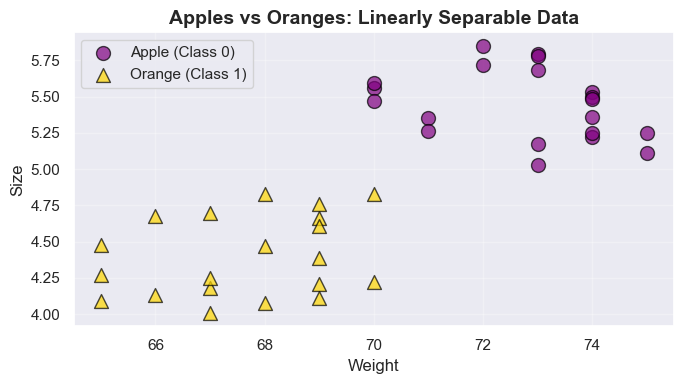

In [128]:
# Visualize the data
plt.figure(figsize=(7, 4))
plt.scatter(apples_oranges[apples_oranges['Class']==0]['Weight'], 
            apples_oranges[apples_oranges['Class']==0]['Size'], 
            c='purple', marker='o', s=100, alpha=0.7, label='Apple (Class 0)', edgecolors='black')
plt.scatter(apples_oranges[apples_oranges['Class']==1]['Weight'], 
            apples_oranges[apples_oranges['Class']==1]['Size'], 
            c='gold', marker='^', s=100, alpha=0.7, label='Orange (Class 1)', edgecolors='black')
plt.xlabel('Weight', fontsize=12)
plt.ylabel('Size', fontsize=12)
plt.title('Apples vs Oranges: Linearly Separable Data', fontweight='bold', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observation**: The two classes are clearly separated. We can draw a straight line between apples and oranges - this is **linearly separable data**.

#### Building Logistic Regression with Raw Features

For linearly separable data, the standard logistic regression hypothesis works perfectly:

$$
h_w(x) = \sigma(w_0 + w_1 x_1 + w_2 x_2)
$$

where:

- $\sigma$ is the sigmoid function
- $w_0$ is the intercept
- $w_1, w_2$ are coefficients for Weight and Size
- The decision boundary occurs where $w_0 + w_1 x_1 + w_2 x_2 = 0$

In [129]:
# Prepare features and target
X_apples = apples_oranges[['Weight', 'Size']]
y_apples = apples_oranges['Class']

# Train logistic regression model
linear_model = LogisticRegression()
linear_model.fit(X_apples, y_apples)

# Make predictions
y_pred_apples = linear_model.predict(X_apples)

# Evaluate performance
accuracy = accuracy_score(y_apples, y_pred_apples)
print(f"Model Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"\nModel Parameters:")
print(f"  Intercept (w₀): {linear_model.intercept_[0]:.4f}")
print(f"  Weight coefficient (w₁): {linear_model.coef_[0][0]:.4f}")
print(f"  Size coefficient (w₂): {linear_model.coef_[0][1]:.4f}")

Model Accuracy: 1.0000 (100.0%)

Model Parameters:
  Intercept (w₀): 106.6029
  Weight coefficient (w₁): -1.4283
  Size coefficient (w₂): -1.3129


#### Visualizing the Linear Decision Boundary

The decision boundary is a straight line defined by: $w_0 + w_1 \cdot \text{Weight} + w_2 \cdot \text{Size} = 0$

Rearranging: $\text{Size} = -\frac{w_0}{w_2} - \frac{w_1}{w_2} \cdot \text{Weight}$

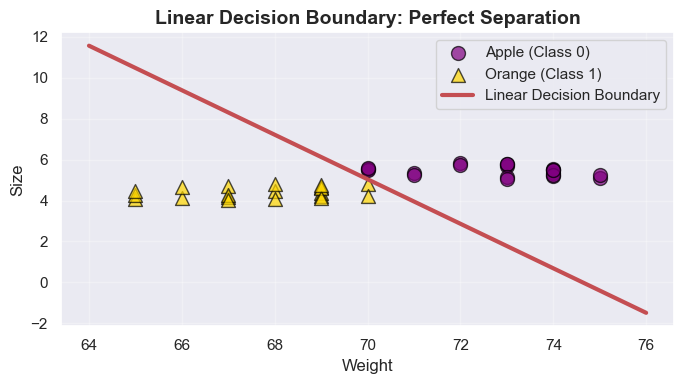

In [130]:
# Extract model parameters
w0 = linear_model.intercept_[0]
w1 = linear_model.coef_[0][0]
w2 = linear_model.coef_[0][1]

# Calculate decision boundary line
weight_range = np.array([apples_oranges['Weight'].min() - 1, apples_oranges['Weight'].max() + 1])
size_boundary = -(w0 / w2) - (w1 / w2) * weight_range

# Plot data with decision boundary
plt.figure(figsize=(7, 4))
plt.scatter(apples_oranges[apples_oranges['Class']==0]['Weight'], 
            apples_oranges[apples_oranges['Class']==0]['Size'], 
            c='purple', marker='o', s=100, alpha=0.7, label='Apple (Class 0)', edgecolors='black')
plt.scatter(apples_oranges[apples_oranges['Class']==1]['Weight'], 
            apples_oranges[apples_oranges['Class']==1]['Size'], 
            c='gold', marker='^', s=100, alpha=0.7, label='Orange (Class 1)', edgecolors='black')
plt.plot(weight_range, size_boundary, 'r-', linewidth=3, label='Linear Decision Boundary')
plt.xlabel('Weight', fontsize=12)
plt.ylabel('Size', fontsize=12)
plt.title('Linear Decision Boundary: Perfect Separation', fontweight='bold', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Key Takeaway**: When data is **linearly separable**, a straight-line decision boundary (using raw features) achieves perfect classification. No feature transformation is needed.


### Nonlinear Decision Boundary (Non-Linearly Separable Data)

In some cases, we encounter data where classes cannot be separated by a straight line. Consider the training data distribution illustrated below:

<img src="datasets/nonlinear_boundary.png" alt="Nonlinear Decision Boundary" width="50%">

When confronted with such a circular or curved pattern, it becomes imperative to generate polynomial features (such as $x_1^2, x_2^2$) in order to enhance the delineation between the two classes. 

Let's delve into a concrete example using a microchip quality control dataset. For the purpose of illustrating the decision boundary clearly, I chose not to split the data into training and test sets.

In [131]:
# Load the microchip quality control dataset
microchip_test = pd.read_csv('datasets/ex2data2.txt', header=None, 
                         names=['test_1', 'test_2', 'faulty'])

print(f"Dataset shape: {microchip_test.shape}")
print(f"\nClass distribution:")
print(microchip_test['faulty'].value_counts())
print(f"\n0 = Pass (Non-Faulty), 1 = Fail (Faulty)")
microchip_test.head()

Dataset shape: (118, 3)

Class distribution:
faulty
0    60
1    58
Name: count, dtype: int64

0 = Pass (Non-Faulty), 1 = Fail (Faulty)


,test_1,test_2,faulty
0,0.051267,0.69956,1
1,-0.092742,0.68494,1
2,-0.213710,0.69225,1
3,-0.375000,0.50219,1
4,-0.513250,0.46564,1


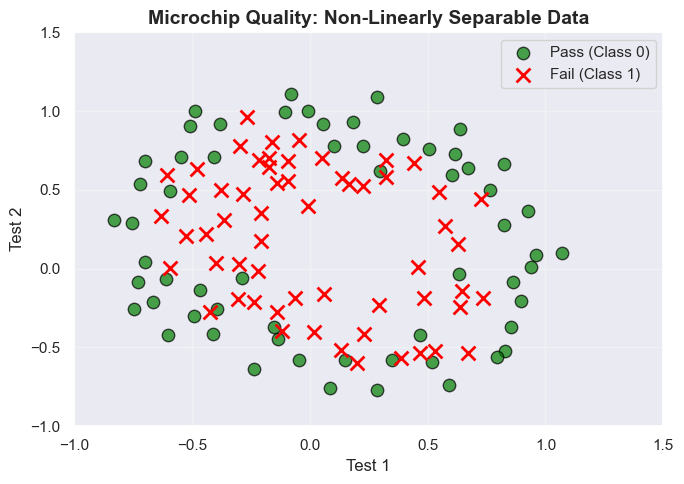

In [132]:
# Visualize the data
plt.figure(figsize=(7, 5))
pos = microchip_test['faulty'] == 1
neg = microchip_test['faulty'] == 0

plt.scatter(microchip_test.loc[neg, 'test_1'], microchip_test.loc[neg, 'test_2'], 
            c='green', marker='o', s=80, alpha=0.7, label='Pass (Class 0)', edgecolors='black')
plt.scatter(microchip_test.loc[pos, 'test_1'], microchip_test.loc[pos, 'test_2'], 
            c='red', marker='x', s=100, linewidths=2, label='Fail (Class 1)')
plt.xlabel('Test 1', fontsize=12)
plt.ylabel('Test 2', fontsize=12)
plt.title('Microchip Quality: Non-Linearly Separable Data', fontweight='bold', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(-1, 1.5)
plt.ylim(-1, 1.5)
plt.tight_layout()
plt.show()

**Observation**: The faulty microchips (red X's) are surrounded by passing microchips (green circles). **No straight line can separate these two classes** - the data exhibits a circular pattern and is not linearly separable.

#### Step 1: Attempt with Raw Features (Linear Model - Will Fail)

Let's first try logistic regression with only the raw features to demonstrate why transformation is necessary.

In [133]:
# Prepare features and target
X_raw = microchip_test[['test_1', 'test_2']]
y = microchip_test['faulty']

# Train linear logistic regression with raw features
linear_model = LogisticRegression()
linear_model.fit(X_raw, y)

# Evaluate performance
y_pred_linear = linear_model.predict(X_raw)
accuracy_linear = accuracy_score(y, y_pred_linear)

print(f"Linear Model (Raw Features) Performance:")
print(f"  Accuracy: {accuracy_linear:.4f} ({accuracy_linear*100:.1f}%)")
print(f"\n⚠️ Poor performance! Linear model cannot capture the circular pattern.")

Linear Model (Raw Features) Performance:
  Accuracy: 0.5424 (54.2%)

⚠️ Poor performance! Linear model cannot capture the circular pattern.


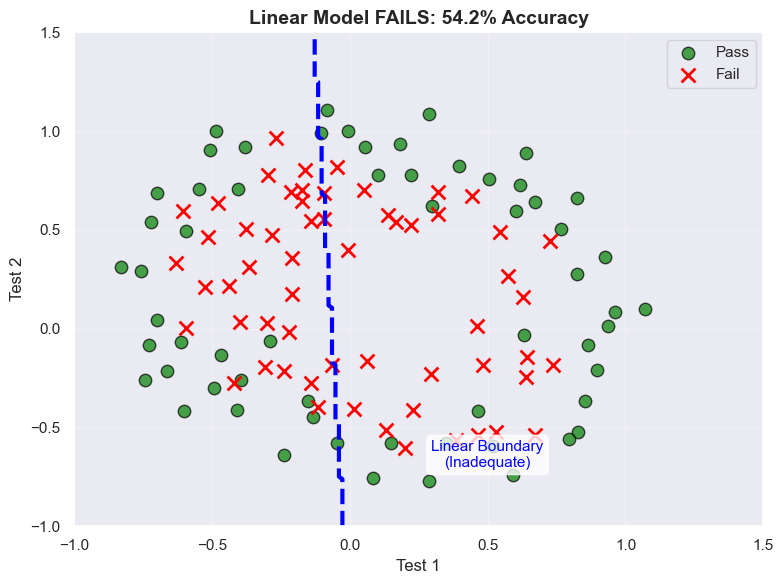

❌ The straight-line boundary cannot capture the circular separation pattern!


In [134]:
# Visualize the linear decision boundary (inadequate for circular pattern)
fig, ax = plt.subplots(figsize=(8, 6))

# Plot data points
ax.scatter(microchip_test.loc[neg, 'test_1'], microchip_test.loc[neg, 'test_2'], 
           c='green', marker='o', s=80, alpha=0.7, label='Pass', edgecolors='black')
ax.scatter(microchip_test.loc[pos, 'test_1'], microchip_test.loc[pos, 'test_2'], 
           c='red', marker='x', s=100, linewidths=2, label='Fail')

# Create mesh for linear decision boundary
xx, yy = np.meshgrid(np.linspace(-1, 1.5, 200), np.linspace(-1, 1.5, 200))
mesh_data = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=['test_1', 'test_2'])
Z_linear = linear_model.predict(mesh_data)
Z_linear = Z_linear.reshape(xx.shape)

# Plot linear decision boundary
ax.contour(xx, yy, Z_linear, levels=[0.5], colors='blue', linewidths=3, linestyles='dashed')
ax.text(0.5, -0.7, 'Linear Boundary\n(Inadequate)', fontsize=11, color='blue', 
        ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Test 1', fontsize=12)
ax.set_ylabel('Test 2', fontsize=12)
ax.set_title(f'Linear Model FAILS: {accuracy_linear*100:.1f}% Accuracy', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1, 1.5)
ax.set_ylim(-1, 1.5)
plt.tight_layout()
plt.show()

print("❌ The straight-line boundary cannot capture the circular separation pattern!")

### Step 2: Polynomial Feature Transformation (The Solution)

**Key Insight**: Transform the original features into higher-order polynomial features to enable nonlinear decision boundaries.

**Original features**: $x_1, x_2$ (Test 1, Test 2)

**Polynomial features (degree 2)**: $1, x_1, x_2, x_1^2, x_1 x_2, x_2^2$ (6 features)

**Polynomial features (degree 6)**: 28 features including all combinations up to degree 6

This allows logistic regression to learn curves and circles while remaining a linear model in the transformed feature space.

In [135]:
from scipy.optimize import minimize

# Helper functions for polynomial feature transformation
def mapFeature(X1, X2, degree):
    """Map features to polynomial features up to given degree"""
    res = np.ones(X1.shape[0])
    for i in range(1, degree + 1):
        for j in range(0, i + 1):
            res = np.column_stack((res, (X1 ** (i-j)) * (X2 ** j)))
    return res

def sigmoid(z):
    """Sigmoid activation function"""
    return 1 / (1 + np.exp(-z))

def costFunc(theta, X, y):
    """Logistic regression cost function"""
    m = y.shape[0]
    z = X.dot(theta)
    h = sigmoid(z)
    term1 = y * np.log(h)
    term2 = (1 - y) * np.log(1 - h)
    J = -np.sum(term1 + term2, axis=0) / m
    return J

def plotDecisionBoundary(theta, degree, ax):
    """Plot nonlinear decision boundary"""
    u = np.linspace(-1, 1.5, 100)
    v = np.linspace(-1, 1.5, 100)
    U, V = np.meshgrid(u, v)
    U_flat = np.ravel(U)
    V_flat = np.ravel(V)
    
    X_poly = mapFeature(U_flat, V_flat, degree)
    Z = X_poly.dot(theta)
    Z = Z.reshape(U.shape)
    
    ax.contour(U, V, Z, levels=[0], colors='purple', linewidths=3)
    return ax

# Train polynomial models with degrees 2, 3, 4, 5, and 6
results = {}

for degree in [2, 3, 4, 5, 6]:
    # Transform features to polynomial
    X_poly = mapFeature(microchip_test['test_1'], microchip_test['test_2'], degree)
    
    # Initialize parameters
    initial_theta = np.zeros(X_poly.shape[1])
    
    # Optimize using BFGS
    res = minimize(costFunc, initial_theta, args=(X_poly, y), method='BFGS')
    theta = res.x
    
    # Evaluate
    predictions = sigmoid(X_poly.dot(theta)) >= 0.5
    accuracy = accuracy_score(y, predictions)
    
    results[degree] = {'theta': theta, 'accuracy': accuracy, 'n_features': X_poly.shape[1]}
    
    print(f"Degree {degree} Polynomial:")
    print(f"  Number of features: {X_poly.shape[1]} (from 2 original features)")
    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
    print()

Degree 2 Polynomial:
  Number of features: 6 (from 2 original features)
  Accuracy: 0.8559 (85.6%)

Degree 3 Polynomial:
  Number of features: 10 (from 2 original features)
  Accuracy: 0.8475 (84.7%)

Degree 4 Polynomial:
  Number of features: 15 (from 2 original features)
  Accuracy: 0.8475 (84.7%)

Degree 5 Polynomial:
  Number of features: 21 (from 2 original features)
  Accuracy: 0.8814 (88.1%)

Degree 6 Polynomial:
  Number of features: 28 (from 2 original features)
  Accuracy: 0.9153 (91.5%)



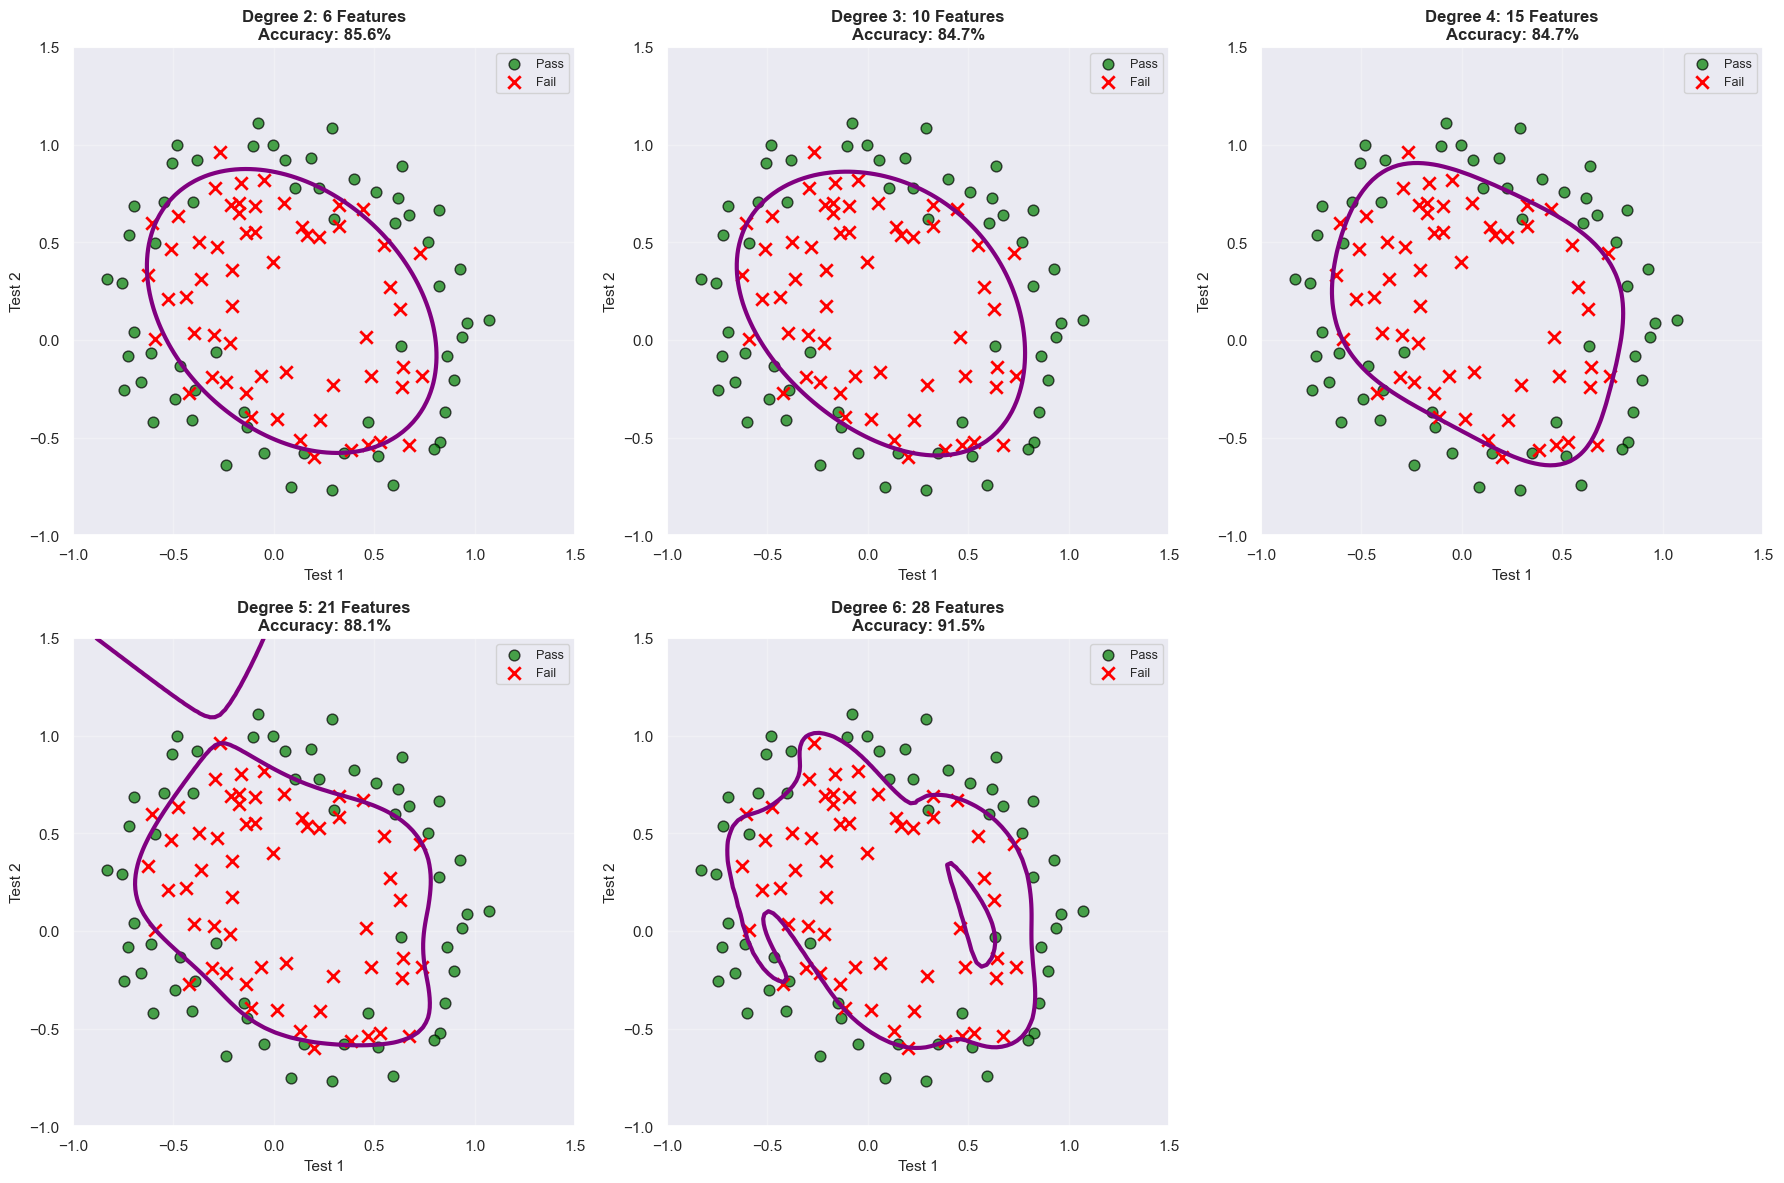

In [136]:
# Visualize all decision boundaries in a grid layout
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, degree in enumerate([2, 3, 4, 5, 6]):
    ax = axes[idx]
    
    # Plot data points
    ax.scatter(microchip_test.loc[neg, 'test_1'], microchip_test.loc[neg, 'test_2'], 
               c='green', marker='o', s=60, alpha=0.7, label='Pass', edgecolors='black')
    ax.scatter(microchip_test.loc[pos, 'test_1'], microchip_test.loc[pos, 'test_2'], 
               c='red', marker='x', s=80, linewidths=2, label='Fail')
    
    # Plot decision boundary
    theta = results[degree]['theta']
    plotDecisionBoundary(theta, degree, ax)
    
    accuracy = results[degree]['accuracy']
    n_features = results[degree]['n_features']
    
    ax.set_xlabel('Test 1', fontsize=11)
    ax.set_ylabel('Test 2', fontsize=11)
    ax.set_title(f'Degree {degree}: {n_features} Features\nAccuracy: {accuracy*100:.1f}%', 
                 fontweight='bold', fontsize=12)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-1, 1.5)
    ax.set_ylim(-1, 1.5)

# Hide the 6th subplot (bottom right)
axes[5].axis('off')

plt.tight_layout()
plt.show()

### Analysis: Finding the Right Balance

**Degree 2 Polynomial (6 features)**:
- ✅ **Good fit**: Creates a smooth circular boundary that captures the general pattern
- ✅ **Good generalization**: The boundary is not overly complex
- ✅ **Interpretable**: Simple polynomial terms like $x_1^2 + x_2^2$ represent circles

**Degree 3 Polynomial (10 features)**:
- ✅ **Better fit**: Captures more nuances in the data
- ✅ **Still reasonable**: Adds some flexibility without excessive complexity
- ⚠️ **Slight increase in complexity**: Boundary becomes slightly more irregular

**Degree 4 Polynomial (15 features)**:
- ⚠️ **Starting to overfit**: Boundary begins to follow training data too closely
- ⚠️ **Increased complexity**: More parameters to learn
- ⚠️ **Diminishing returns**: Accuracy gains become smaller

**Degree 5 Polynomial (21 features)**:
- ⚠️ **Overfitting evident**: Boundary shows noticeable irregularities
- ⚠️ **High complexity**: Many parameters relative to data size
- ❌ **Poor generalization potential**: Likely to fail on new data

**Degree 6 Polynomial (28 features)**:
- ❌ **Severe overfitting**: Tries to perfectly classify every training point
- ❌ **Too complex**: Creates very wiggly, irregular boundaries
- ❌ **Poor generalization**: Will likely fail on new data
- ❌ **Uninterpretable**: 28 features with high-order interactions

**Key Lesson**: As polynomial degree increases, we see a progression from underfitting → good fit → overfitting. The optimal degree (typically 2-3 for this data) balances model complexity with generalization. **Too many features cause overfitting** - the model memorizes training data rather than learning the underlying pattern.


### Summary: Polynomial Feature Transformation

We've seen how **polynomial feature transformation** enables logistic regression to learn nonlinear decision boundaries:
 Polynomial features work well for capturing geometric nonlinear patterns (circles, ellipses, curves), but they come with tradeoffs:
- ✅ **Pros**: Captures complex boundaries, mathematically elegant
- ⚠️ **Cons**: Feature explosion (grows rapidly with degree), overfitting risk, computational cost



### Beyond Polynomial Transformations

While polynomial features are powerful for capturing certain types of nonlinear relationships, they are **not the only tool** for feature engineering in classification problems. Other transformation techniques can be equally or more effective depending on the data characteristics:

**1. Log Transformation**
- **Purpose**: Handles skewed distributions, reduces impact of outliers
- **When to use**: Features with exponential growth patterns or heavy right skew
- **Example**: Transforming fare prices, income, or counts

**2. Binning Continuous Variables**
- **Purpose**: Converts continuous features into categorical groups
- **When to use**: Non-smooth relationships, domain-based groupings (age groups, price ranges)
- **Benefit**: Captures threshold effects and categorical patterns

**3. Interaction Terms**
- **Purpose**: Captures combined effects of multiple features
- **When to use**: When one feature's impact depends on another (e.g., age effect varies by passenger class)

**4. Manually Creating New Features**
- **Purpose**: Derive meaningful features by combining or transforming existing ones
- **When to use**: Domain knowledge suggests useful feature combinations
- **Example**: Creating `family_size` by adding `siblings/spouses` + `parents/children` counts
- **Benefit**: Can capture domain-specific patterns more effectively than automatic transformations

In the following sections, we'll demonstrate these transformations using a real-world dataset where **polynomial features alone may not be the best choice**. The Titanic dataset provides an excellent case study because:
- Survival patterns involve **categorical groupings** (e.g., children vs. adults)
- Features like fare are **heavily skewed**
- Effects are **context-dependent** (e.g., gender's impact varies by class)

Let's explore how these alternative transformations can be more effective than polynomials for real-world classification problems.



## Practical Example: Feature Engineering with Titanic Dataset

**Important Learning Objective**: This example demonstrates that **not all feature engineering attempts succeed**. Unlike the microchip example where polynomial features dramatically improved performance, we'll see that real-world feature engineering is often a process of trial, testing, and honest evaluation.

### Why This Example Is Valuable

The Titanic dataset presents fundamentally different challenges than the microchip example:

| **Microchip Dataset** | **Titanic Dataset** |
|----------------------|---------------------|
| Geometric circular pattern | Complex social and demographic patterns |
| Polynomial features: Dramatic improvement | Feature engineering: Mixed results |
| 2 continuous features | Mix of continuous and categorical features |
| Clear nonlinear relationship | Already well-captured by raw features |

### Hypotheses to Test

Based on domain knowledge about Titanic survival, we might expect:

- **Threshold Effects**: Children (age < 12) had higher survival rates → suggests age binning might help
- **Skewed Distributions**: Fare prices are right-skewed → suggests fare grouping might help
-  **Interaction Effects**: Gender's impact varied by class → suggests sex×pclass interaction might help
- **Combined Features**: Family size mattered → suggests combining sibsp + parch might help

### Our Experimental Approach

We'll systematically test **three feature engineering strategies** and evaluate whether they actually improve performance:

1. **Baseline Model** - Raw features only (establishes performance floor)
2. **Step 1: Combined features** - family_size = sibsp + parch
3. **Step 2: Interaction terms** - sex × pclass
4. **Step 3: Binned features** - age_group, fare_group

**Starting features:**
```python
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']
```
Where `sibsp` = siblings/spouses aboard, `parch` = parents/children aboard

### The Real Lesson

This example will demonstrate:
- **Feature engineering is trial-and-error** - not every logical idea improves performance
- **Testing is essential** - domain knowledge suggests features, but data decides if they help
- **Sometimes the baseline is hard to beat** - raw features may already capture the patterns well
- **Be willing to discard features** - if engineered features don't help, stick with the simpler model

Let's see what actually happens!

### Load and Explore the Titanic Dataset

In [137]:
# Load the Titanic dataset from seaborn
titanic = sns.load_dataset('titanic')

print(f"\nSurvival distribution:")
print(titanic['survived'].value_counts())
print(f"\nSurvival rate: {titanic['survived'].mean():.2%}")

print(f"Dataset shape: {titanic.shape}")
print(f"\nFirst few rows:")
titanic.head()



Survival distribution:
survived
0    549
1    342
Name: count, dtype: int64

Survival rate: 38.38%
Dataset shape: (891, 15)

First few rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


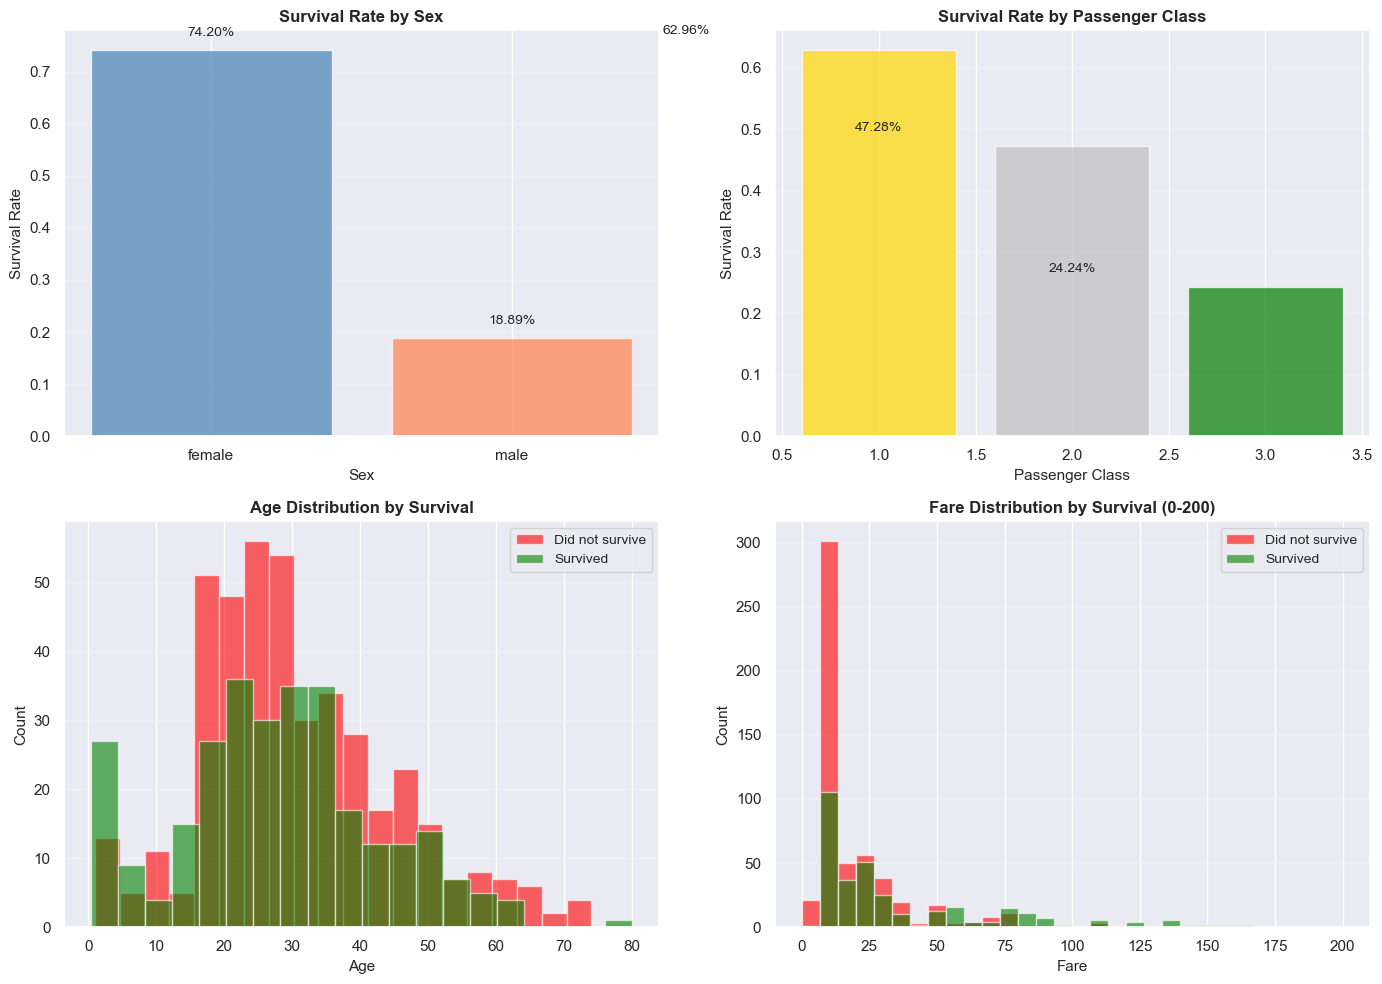

In [138]:
# Visualize survival rates by key features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Survival by Sex
sex_survival = titanic.groupby('sex')['survived'].mean()
axes[0, 0].bar(sex_survival.index, sex_survival.values, color=['steelblue', 'coral'], alpha=0.7)
axes[0, 0].set_xlabel('Sex', fontsize=11)
axes[0, 0].set_ylabel('Survival Rate', fontsize=11)
axes[0, 0].set_title('Survival Rate by Sex', fontweight='bold', fontsize=12)
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(sex_survival.values):
    axes[0, 0].text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom', fontsize=10)

# Survival by Passenger Class
class_survival = titanic.groupby('pclass')['survived'].mean()
axes[0, 1].bar(class_survival.index, class_survival.values, color=['gold', 'silver', 'green'], alpha=0.7)
axes[0, 1].set_xlabel('Passenger Class', fontsize=11)
axes[0, 1].set_ylabel('Survival Rate', fontsize=11)
axes[0, 1].set_title('Survival Rate by Passenger Class', fontweight='bold', fontsize=12)
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_survival.values):
    axes[0, 1].text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom', fontsize=10)

# Survival by Age Distribution
axes[1, 0].hist(titanic[titanic['survived']==0]['age'].dropna(), bins=20, alpha=0.6, label='Did not survive', color='red')
axes[1, 0].hist(titanic[titanic['survived']==1]['age'].dropna(), bins=20, alpha=0.6, label='Survived', color='green')
axes[1, 0].set_xlabel('Age', fontsize=11)
axes[1, 0].set_ylabel('Count', fontsize=11)
axes[1, 0].set_title('Age Distribution by Survival', fontweight='bold', fontsize=12)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(axis='y', alpha=0.3)

# Survival by Fare Distribution
axes[1, 1].hist(titanic[titanic['survived']==0]['fare'].dropna(), bins=30, alpha=0.6, label='Did not survive', color='red', range=(0, 200))
axes[1, 1].hist(titanic[titanic['survived']==1]['fare'].dropna(), bins=30, alpha=0.6, label='Survived', color='green', range=(0, 200))
axes[1, 1].set_xlabel('Fare', fontsize=11)
axes[1, 1].set_ylabel('Count', fontsize=11)
axes[1, 1].set_title('Fare Distribution by Survival (0-200)', fontweight='bold', fontsize=12)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


**Key Observations from Exploration:**
* Women had much higher survival rates than men (74.20% vs 18.89%)
* First class passengers had higher survival rates (62.96%) than third class (24.24%)
* Children appear to have higher survival rates (visible in age distribution)
* Fare prices are heavily right-skewed (most passengers paid low fares)

### Data Preprocessing and Train/Test Split

Before building models, we need to:
1. Select relevant features
2. Handle missing values
3. Encode categorical variables
4. Split into training and test sets

In [139]:
from sklearn.model_selection import train_test_split

# Select relevant features for modeling
# We'll use: pclass, sex, age, sibsp (siblings/spouses), parch (parents/children), fare
features_to_use = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']

# Create a clean dataset
titanic_clean = titanic[features_to_use + ['survived']].copy()

# Handle missing values
print("Missing values before cleaning:")
print(titanic_clean.isnull().sum())

# Fill missing age with median age
titanic_clean['age'] = titanic_clean['age'].fillna(titanic_clean['age'].median())

# Fill missing fare with median fare
titanic_clean['fare'] = titanic_clean['fare'].fillna(titanic_clean['fare'].median())

# Encode categorical variables (sex: male=1, female=0)
titanic_clean['sex'] = (titanic_clean['sex'] == 'male').astype(int)

print("\nMissing values after cleaning:")
print(titanic_clean.isnull().sum())
print(f"\nCleaned dataset shape: {titanic_clean.shape}")
print(f"\nFirst few rows after preprocessing:")
print(titanic_clean.head())

Missing values before cleaning:
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
survived      0
dtype: int64

Missing values after cleaning:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
survived    0
dtype: int64

Cleaned dataset shape: (891, 7)

First few rows after preprocessing:
   pclass  sex   age  sibsp  parch     fare  survived
0       3    1  22.0      1      0   7.2500         0
1       1    0  38.0      1      0  71.2833         1
2       3    0  26.0      0      0   7.9250         1
3       1    0  35.0      1      0  53.1000         1
4       3    1  35.0      0      0   8.0500         0


In [140]:
# Split into features (X) and target (y)
X = titanic_clean.drop('survived', axis=1)
y = titanic_clean['survived']

# Split into training and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set survival rate: {y_train.mean():.2%}")
print(f"Test set survival rate: {y_test.mean():.2%}")
print(f"\nFeatures: {list(X.columns)}")

Training set size: 712 samples
Test set size: 179 samples

Training set survival rate: 38.34%
Test set survival rate: 38.55%

Features: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']


### Model 1: Baseline Model (Raw Features Only)

Let's start with a simple logistic regression model using only the raw features (no transformations). This serves as our baseline for comparison.

In [141]:
# Train baseline model with raw features
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)

# Make predictions
y_train_pred_baseline = baseline_model.predict(X_train)
y_test_pred_baseline = baseline_model.predict(X_test)

# Evaluate performance
train_acc_baseline = accuracy_score(y_train, y_train_pred_baseline)
test_acc_baseline = accuracy_score(y_test, y_test_pred_baseline)

print(f"Baseline Model (Raw Features) Performance:")
print(f"  Training Accuracy: {train_acc_baseline:.4f} ({train_acc_baseline*100:.1f}%)")
print(f"  Test Accuracy: {test_acc_baseline:.4f} ({test_acc_baseline*100:.1f}%)")

# Display feature coefficients
print(f"\nFeature Coefficients:")
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': baseline_model.coef_[0]
}).sort_values('Coefficient', ascending=False)
print(coef_df.to_string(index=False))

print(f"\nInterpretation:")
print(f"  • Negative coefficient for 'sex': Being male (sex=1) decreases survival probability")
print(f"  • Negative coefficient for 'pclass': Higher class number (3rd class) decreases survival")
print(f"  • Features with positive coefficients increase survival probability")

Baseline Model (Raw Features) Performance:
  Training Accuracy: 0.7921 (79.2%)
  Test Accuracy: 0.8045 (80.4%)

Feature Coefficients:
Feature  Coefficient
   fare     0.003219
    age    -0.038486
  parch    -0.100630
  sibsp    -0.267350
 pclass    -1.051361
    sex    -2.612639

Interpretation:
  • Negative coefficient for 'sex': Being male (sex=1) decreases survival probability
  • Negative coefficient for 'pclass': Higher class number (3rd class) decreases survival
  • Features with positive coefficients increase survival probability


### Testing Feature Engineering Hypotheses

Now we'll **incrementally test** different types of engineered features, one at a time, to see if they actually improve model performance. This is **real-world feature engineering** - we propose features based on domain knowledge, then let the data tell us if they help.

**Starting point**: 6 raw features → `['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']`

**Critical mindset**: Each step we'll ask: "Does this engineered feature actually help, or should we discard it?"

We'll test:
1. **Combined features** (family_size) - Does total family size matter more than separate counts?
2. **Interaction terms** (sex × pclass) - Does gender's effect truly vary by class?
3. **Binned features** (age_group, fare_group) - Do categorical bins beat continuous values?

Let's find out what actually works! 

#### Step 1: Add Combined Feature (family_size)

**Feature Engineering Technique**: Combining related features to capture domain-specific patterns

**Why**: `sibsp` (siblings/spouses) and `parch` (parents/children) separately may not be as predictive as knowing the **total family size**. Families traveling together had different survival patterns.

**New feature**: `family_size = sibsp + parch`

In [142]:
# Step 1: Add family_size feature
X_train_step1 = X_train.copy()
X_test_step1 = X_test.copy()

# Create family_size by combining sibsp and parch
X_train_step1['family_size'] = X_train_step1['sibsp'] + X_train_step1['parch']
X_test_step1['family_size'] = X_test_step1['sibsp'] + X_test_step1['parch']

print(f"Feature Engineering Step 1:")
print(f"   Original features: {X_train.shape[1]}")
print(f"   After adding family_size: {X_train_step1.shape[1]}")
print(f"   New feature: family_size = sibsp + parch")
print(f"\n   Sample values:")
print(X_train_step1[['sibsp', 'parch', 'family_size']].head())

# Train model
model_step1 = LogisticRegression(max_iter=1000, random_state=42)
model_step1.fit(X_train_step1, y_train)

# Evaluate
y_pred_step1 = model_step1.predict(X_test_step1)
acc_step1 = accuracy_score(y_test, y_pred_step1)

print(f"\n✅ Model Performance:")
print(f"   Test Accuracy: {acc_step1:.4f} ({acc_step1*100:.1f}%)")
print(f"   Improvement over baseline: {(acc_step1 - test_acc_baseline)*100:+.2f}%")

Feature Engineering Step 1:
   Original features: 6
   After adding family_size: 7
   New feature: family_size = sibsp + parch

   Sample values:
     sibsp  parch  family_size
692      0      0            0
481      0      0            0
527      0      0            0
855      0      1            1
801      1      1            2

✅ Model Performance:
   Test Accuracy: 0.8101 (81.0%)
   Improvement over baseline: +0.56%


### Step 2: Add Interaction Term (sex × pclass)

**Feature Engineering Technique**: Creating interaction terms to capture context-dependent effects

**Why**: The "women and children first" policy wasn't uniform across all classes. First-class women had much higher survival rates than third-class women. The effect of gender **depends on** passenger class.

**New feature**: `sex_pclass = sex × pclass`

In [143]:
# Step 2: Add interaction term (sex × pclass)
X_train_step2 = X_train_step1.copy()
X_test_step2 = X_test_step1.copy()

# Create interaction between sex and pclass
X_train_step2['sex_pclass'] = X_train_step2['sex'] * X_train_step2['pclass']
X_test_step2['sex_pclass'] = X_test_step2['sex'] * X_test_step2['pclass']

print(f"Feature Engineering Step 2:")
print(f"   Previous features: {X_train_step1.shape[1]}")
print(f"   After adding sex_pclass interaction: {X_train_step2.shape[1]}")
print(f"   New feature: sex_pclass = sex × pclass")
print(f"\n   How it works:")
print(f"   • Male (1) in 3rd class (3): 1 × 3 = 3")
print(f"   • Male (1) in 1st class (1): 1 × 1 = 1")
print(f"   • Female (0) in any class: 0 × pclass = 0")

# Train model
model_step2 = LogisticRegression(max_iter=1000, random_state=42)
model_step2.fit(X_train_step2, y_train)

# Evaluate
y_pred_step2 = model_step2.predict(X_test_step2)
acc_step2 = accuracy_score(y_test, y_pred_step2)

print(f"\n✅ Model Performance:")
print(f"   Test Accuracy: {acc_step2:.4f} ({acc_step2*100:.1f}%)")
print(f"   Improvement over Step 1: {(acc_step2 - acc_step1)*100:+.2f}%")
print(f"   Improvement over baseline: {(acc_step2 - test_acc_baseline)*100:+.2f}%")

Feature Engineering Step 2:
   Previous features: 7
   After adding sex_pclass interaction: 8
   New feature: sex_pclass = sex × pclass

   How it works:
   • Male (1) in 3rd class (3): 1 × 3 = 3
   • Male (1) in 1st class (1): 1 × 1 = 1
   • Female (0) in any class: 0 × pclass = 0

✅ Model Performance:
   Test Accuracy: 0.8101 (81.0%)
   Improvement over Step 1: +0.00%
   Improvement over baseline: +0.56%


### Step 3: Add Binned Features (age_group, fare_group)

**Feature Engineering Technique**: Converting continuous variables into categorical bins

**Why**: 
- **Age**: Children (< 12) had distinctly higher survival rates - a threshold effect that's better captured by categories than smooth curves
- **Fare**: Heavily right-skewed with outliers. Grouping into price ranges (low/medium/high/premium) can be more robust than raw values

**New features**: `age_group` (5 categories), `fare_group` (4 categories)

C:\Users\lsi8012\AppData\Local\Temp\ipykernel_11776\3460317799.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_group = titanic_clean.groupby('age_group')['survived'].mean()


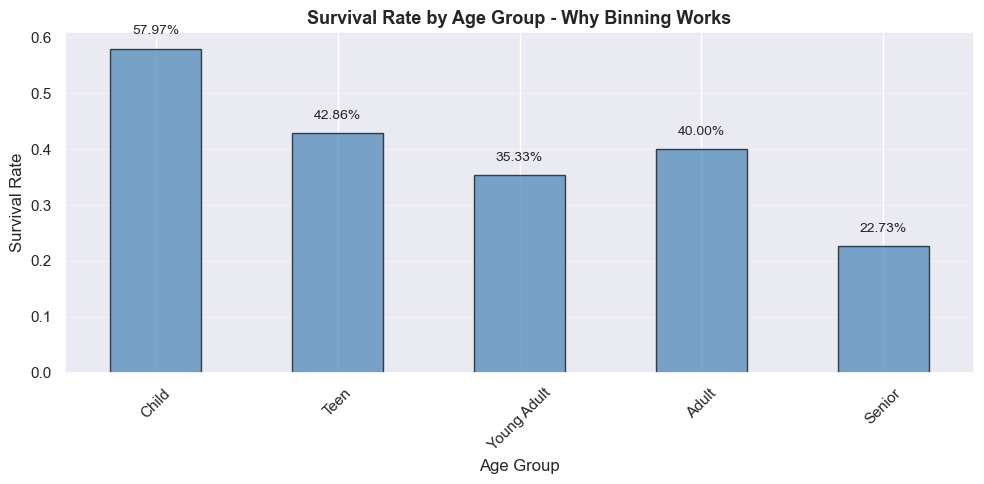

Survival rates by age group:
   • Child: 57.97%
   • Teen: 42.86%
   • Young Adult: 35.33%
   • Adult: 40.00%
   • Senior: 22.73%

Notice the clear threshold: Children have distinctly higher survival!


In [144]:
# First, let's visualize why binning makes sense for age
age_bins_analysis = [0, 12, 18, 35, 60, 100]
age_labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
titanic_clean['age_group'] = pd.cut(titanic_clean['age'], bins=age_bins_analysis, labels=age_labels)

survival_by_group = titanic_clean.groupby('age_group')['survived'].mean()
plt.figure(figsize=(10, 5))
survival_by_group.plot(kind='bar', color='steelblue', alpha=0.7, edgecolor='black')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.title('Survival Rate by Age Group - Why Binning Works', fontweight='bold', fontsize=13)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(survival_by_group.values):
    plt.text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("Survival rates by age group:")
for group, rate in survival_by_group.items():
    print(f"   • {group}: {rate:.2%}")
print("\nNotice the clear threshold: Children have distinctly higher survival!")

In [145]:
# Step 4: Add binned features
X_train_step3 = X_train_step2.copy()
X_test_step3 = X_test_step2.copy()

# Create age bins
age_bins = [0, 12, 18, 35, 60, 100]
X_train_step3['age_group'] = pd.cut(X_train_step3['age'], bins=age_bins, labels=[0, 1, 2, 3, 4], include_lowest=True)
X_test_step3['age_group'] = pd.cut(X_test_step3['age'], bins=age_bins, labels=[0, 1, 2, 3, 4], include_lowest=True)
X_train_step3['age_group'] = X_train_step3['age_group'].astype(int)
X_test_step3['age_group'] = X_test_step3['age_group'].astype(int)

# Create fare bins
fare_bins = [0, 10, 30, 100, 1000]
X_train_step3['fare_group'] = pd.cut(X_train_step3['fare'], bins=fare_bins, labels=[0, 1, 2, 3], include_lowest=True)
X_test_step3['fare_group'] = pd.cut(X_test_step3['fare'], bins=fare_bins, labels=[0, 1, 2, 3], include_lowest=True)
X_train_step3['fare_group'] = X_train_step3['fare_group'].astype(int)
X_test_step3['fare_group'] = X_test_step3['fare_group'].astype(int)

print(f"Feature Engineering Step 4:")
print(f"   Previous features: {X_train_step2.shape[1]}")
print(f"   After adding binned features: {X_train_step3.shape[1]}")
print(f"   New features: age_group, fare_group")
print(f"\n   Age groups: 0=Child, 1=Teen, 2=Young Adult, 3=Adult, 4=Senior")
print(f"   Fare groups: 0=Low(0-10), 1=Medium(10-30), 2=High(30-100), 3=Premium(100+)")

# Train model
model_step3 = LogisticRegression(max_iter=1000, random_state=42)
model_step3.fit(X_train_step3, y_train)

# Evaluate
y_pred_step3 = model_step3.predict(X_test_step3)
acc_step3 = accuracy_score(y_test, y_pred_step3)

# Train model with binned features
model_step4 = LogisticRegression(max_iter=1000, random_state=42)
model_step4.fit(X_train_step3, y_train)

# Evaluate
y_pred_step4 = model_step4.predict(X_test_step3)
acc_step4 = accuracy_score(y_test, y_pred_step4)

print(f"\n✅ Model Performance:")
print(f"   Test Accuracy: {acc_step4:.4f} ({acc_step4*100:.1f}%)")
print(f"   Improvement over Step 3: {(acc_step4 - acc_step2)*100:+.2f}%")
print(f"   Improvement over baseline: {(acc_step4 - test_acc_baseline)*100:+.2f}%")

print(f"\nFinal feature list ({X_train_step3.shape[1]} features):")
print(f"   {list(X_train_step3.columns)}")

Feature Engineering Step 4:
   Previous features: 8
   After adding binned features: 10
   New features: age_group, fare_group

   Age groups: 0=Child, 1=Teen, 2=Young Adult, 3=Adult, 4=Senior
   Fare groups: 0=Low(0-10), 1=Medium(10-30), 2=High(30-100), 3=Premium(100+)

✅ Model Performance:
   Test Accuracy: 0.8045 (80.4%)
   Improvement over Step 3: -0.56%
   Improvement over baseline: +0.00%

Final feature list (10 features):
   ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'sex_pclass', 'age_group', 'fare_group']



### Step-by-Step Performance Comparison

Now let's honestly evaluate whether each feature engineering technique actually improved performance. **Spoiler**: Not all of them did! This is the reality of feature engineering.

STEP-BY-STEP FEATURE ENGINEERING RESULTS
                      Step  Features  Test Accuracy
Baseline\n(6 raw features)         6       0.804469
     Step 1\n+ family_size         7       0.810056
      Step 2\n+ sex×pclass         8       0.810056
   Step 3\n+ age/fare bins        10       0.804469

INCREMENTAL IMPROVEMENTS:
   Step 1 + family_size: +0.56%
   Step 2 + sex×pclass: +0.00%
   Step 3 + age/fare bins: -0.56%

TOTAL IMPROVEMENT FROM BASELINE:
   +0.00% (from 80.4% to 80.4%)


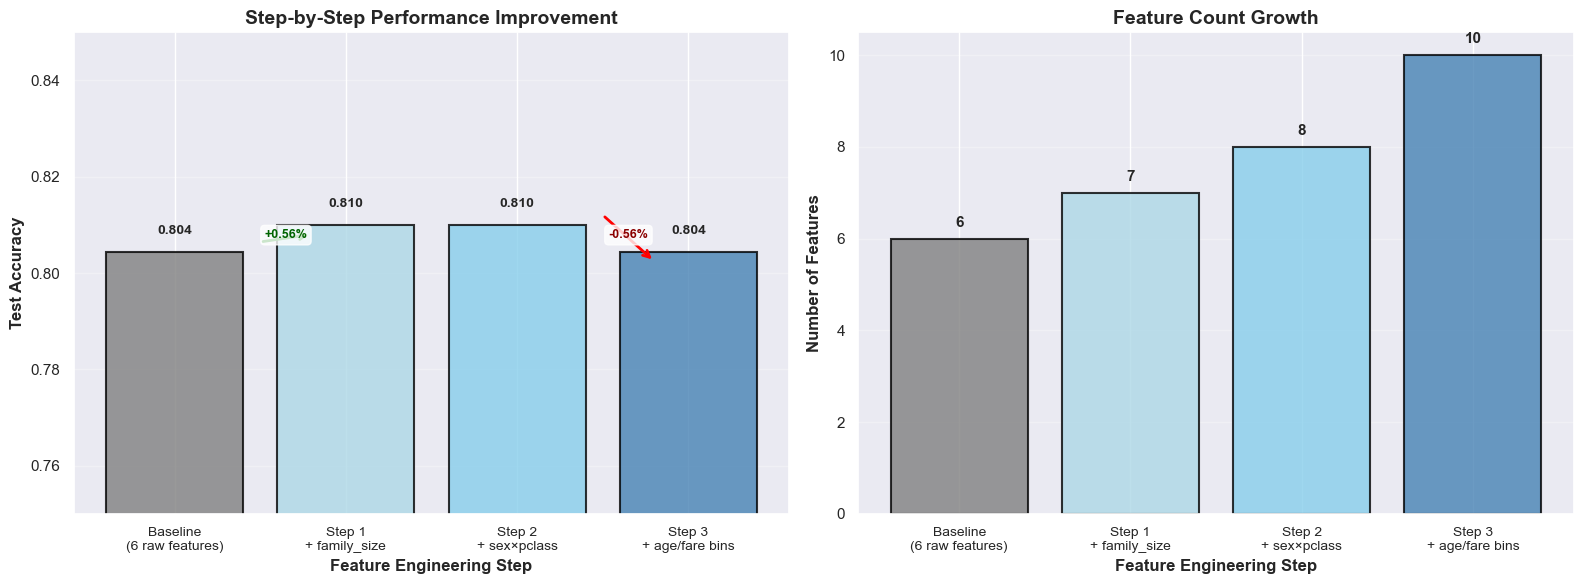

In [147]:
# Create comparison dataframe showing step-by-step improvements
steps_comparison = pd.DataFrame({
    'Step': ['Baseline\n(6 raw features)', 
             'Step 1\n+ family_size', 
             'Step 2\n+ sex×pclass', 
             'Step 3\n+ age/fare bins'],
    'Features': [X_train.shape[1], 
                 X_train_step1.shape[1], 
                 X_train_step2.shape[1], 
                 X_train_step3.shape[1]],
    'Test Accuracy': [test_acc_baseline, acc_step1, acc_step2, acc_step4]
})

print("="*80)
print("STEP-BY-STEP FEATURE ENGINEERING RESULTS")
print("="*80)
print(steps_comparison.to_string(index=False))
print("="*80)

# Calculate incremental improvements
print("\nINCREMENTAL IMPROVEMENTS:")
for i in range(1, len(steps_comparison)):
    prev_acc = steps_comparison.loc[i-1, 'Test Accuracy']
    curr_acc = steps_comparison.loc[i, 'Test Accuracy']
    improvement = (curr_acc - prev_acc) * 100
    step_name = steps_comparison.loc[i, 'Step'].replace('\n', ' ')
    print(f"   {step_name}: {improvement:+.2f}%")

print(f"\nTOTAL IMPROVEMENT FROM BASELINE:")
total_improvement = (acc_step4 - test_acc_baseline) * 100
print(f"   {total_improvement:+.2f}% (from {test_acc_baseline:.1%} to {acc_step4:.1%})")

# Visualize the progression
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Accuracy progression
x = np.arange(len(steps_comparison))
bars = ax1.bar(x, steps_comparison['Test Accuracy'], alpha=0.8, 
               color=['gray', 'lightblue', 'skyblue', 'steelblue', 'darkblue'], 
               edgecolor='black', linewidth=1.5)

ax1.set_xlabel('Feature Engineering Step', fontsize=12, fontweight='bold')
ax1.set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Step-by-Step Performance Improvement', fontweight='bold', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(steps_comparison['Step'], fontsize=10)
ax1.set_ylim(0.75, 0.85)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.003,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add arrows showing improvements
for i in range(len(steps_comparison) - 1):
    x_pos = i + 0.5
    y_start = steps_comparison.loc[i, 'Test Accuracy']
    y_end = steps_comparison.loc[i+1, 'Test Accuracy']
    improvement = (y_end - y_start) * 100
    
    # Show both positive and negative changes
    if abs(improvement) > 0.01:  # Only show if change is noticeable
        arrow_color = 'green' if improvement > 0 else 'red'
        text_color = 'darkgreen' if improvement > 0 else 'darkred'
        sign = '+' if improvement > 0 else ''
        
        ax1.annotate('', xy=(x_pos + 0.3, y_end - 0.002), xytext=(x_pos, y_start + 0.002),
                    arrowprops=dict(arrowstyle='->', color=arrow_color, lw=2))
        ax1.text(x_pos + 0.15, (y_start + y_end) / 2, f'{sign}{improvement:.2f}%',
                fontsize=9, color=text_color, fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Right plot: Feature count progression
bars2 = ax2.bar(x, steps_comparison['Features'], alpha=0.8,
                color=['gray', 'lightblue', 'skyblue', 'steelblue', 'darkblue'],
                edgecolor='black', linewidth=1.5)

ax2.set_xlabel('Feature Engineering Step', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Features', fontsize=12, fontweight='bold')
ax2.set_title('Feature Count Growth', fontweight='bold', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(steps_comparison['Step'], fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.2,
            f'{int(height)}',

            ha='center', va='bottom', fontsize=11, fontweight='bold')


plt.tight_layout()
plt.show()

## Key Insights: What We Actually Learned

### Why Didn't Our Features Help More?

**1. Strong Baseline** - The 6 raw features already captured survival patterns well (~80% accuracy). Titanic survival was driven by clear factors that didn't require complex transformations.

**2. Feature Engineering Isn't Always Necessary** - Unlike the microchip dataset (where polynomial features gave huge gains), these patterns were already well-represented. Adding complexity doesn't help when simpler features work.

**3. Binning Can Lose Information** - Converting continuous values to discrete bins loses granularity. Only bin when there's strong evidence of threshold effects.

**4. Model Limitations** - Logistic regression assumes linear relationships between features and log-odds. Tree-based models (Random Forest, XGBoost) might capture interaction patterns better.

### Key Takeaway

Feature engineering is **trial-and-error**, not magic. The most important skill is **honestly evaluating** whether engineered features actually improve performance. In this case, the baseline was hard to beat, and that's okay! Real data science means reporting what actually happened, not what we hoped would happen.



### Next Steps: Regularization

One technique to prevent overfitting (especially when using many features) is **regularization**. The idea is to penalize the algorithm when it tries to overfit by adding a regularization term to the cost function. 

The New Cost function with regularization is specified as:

$$J(w) = \frac{1}{m} \sum_{i=1}^m[-y_i \log(h_w (z_i)) - (1 - y_i) \log(1-h_w (z_i))] + \frac{\lambda}{2m} \sum_{j=1}^n[w_j^2]$$
                    
where:
- $\lambda$ = regularization factor (controls how much to penalize large weights)
- $n$ = number of features
- **Note**: The regularization term does NOT include the intercept term $w_0$

Regularization will be covered in the next section!